In [ ]:
!pip install info-nce-pytorch

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## slurm

In [ ]:
# sbatch commands
sbatch vertex_1_1_32.slrm
sbatch vertex_1_2_32.slrm
sbatch vertex_2_1_1_32.slrm
sbatch vertex_2_1_2_32.slrm
sbatch vertex_2_2_1_32.slrm
sbatch vertex_2_2_2_32.slrm
sbatch vertex_2_3_1_32.slrm
sbatch vertex_2_3_2_32.slrm
sbatch vertex_3_1_32.slrm
sbatch vertex_3_2_32.slrm
sbatch vertex_3_3_32.slrm

# watch jobs
squeue -u shepp123

# show job details
scontrol show job 5481680
scontrol show job 5481681
scontrol show job 5481682
scontrol show job 5481683
scontrol show job 5481684
scontrol show job 5481685
scontrol show job 5481686
scontrol show job 5481687
scontrol show job 5481688
scontrol show job 5481689
scontrol show job 5481690

scontrol show job 5484228  # 2-2-2

In [29]:
# config
base_dir = '/gpfs/data/fs71925/shepp123/'

def create_slurm(version: str, model_wrapper: str = 'VertexWrapper24x6', model_name: str = 'AutoEncoderVertex', 
                 dataset: str = 'AutoEncoderVertex24x6Dataset', hidden_dims: list[int] = [128, 64, 32], epochs: int = 25_000,
                 sample_count_per_vertex: int = 24000, subset: float|int|None = None, subset_type: list[str]|str|None = None,
                 batch_size: int = 8192, qos: str = 'zen3_0512_a100x2', time: str = '24:00:00'):
    trainer_kwargs = {
        'config_name': 'confmod_auto_encoder.json', 
        'subconfig_name': 'AUTO_ENCODER_VERTEX_24X6', 
        'config_kwargs': {
            'path_train': base_dir + 'frgs_6d',
            'resume': 'run_results/' + version,
            'model_wrapper': model_wrapper,
            'model_name': model_name,
            'dataset': dataset,
            'hidden_dims': hidden_dims,
            'epochs': epochs,
            'sample_count_per_vertex': sample_count_per_vertex, 
            'test_ratio': 0.2, 
            'subset': subset, 
            'subset_type': subset_type,
            'subset_shuffle': False, 
            'devices': 'auto', 
            'device_type': 'gpu', 
            'num_dataloader_workers': 2, 
            'batch_size': batch_size,
        }
    }
    slurm_options = slurm_generate.SlurmOptions(qos=qos, time=time)
    slurm_kwargs = {'project_name': 'vertex_24x6', 'pyenv_dir': base_dir + 'PhysML/.venv', 
                    'trainer': 'vertex.VertexTrainer24x6', 'slurm_options': slurm_options, 'trainer_kwargs': trainer_kwargs}
    slurm_generate.create(script_name='vertex_' + version, **slurm_kwargs)

In [30]:
# test run
create_slurm(version='vsc_test_ae', qos='zen3_0512_a100x2_devel', time='00:05:00')
create_slurm(version='vsc_test_cae', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', sample_count_per_vertex=6000, batch_size=2048, 
             qos='zen3_0512_a100x2_devel', time='00:05:00')

In [31]:
# 1-1 trained on all vertices, simple autoencoder
create_slurm(version='1_1_32')

In [32]:
# 1-2 trained on all vertices, contrastive autoencoder
create_slurm(version='1_2_32', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', epochs=50_000, sample_count_per_vertex=6000, batch_size=2048)

In [33]:
# 2-1-1 exclude SC-phase, simple autoencoder
create_slurm(version='2_1_1_32', subset=0.8, subset_type=['afm', 'fm'])

In [34]:
# 2-1-2 exclude SC-phase, contrastive autoencoder
create_slurm(version='2_1_2_32', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', epochs=50_000, sample_count_per_vertex=6000, subset=0.8, subset_type=['afm', 'fm'], 
             batch_size=2048)

In [35]:
# 2-2-1 exclude AFM-phase, simple autoencoder
create_slurm(version='2_2_1_32', subset=0.8, subset_type=['sc', 'fm'])

In [36]:
# 2-2-2 exclude AFM-phase, contrastive autoencoder
create_slurm(version='2_2_2_32', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', epochs=50_000, sample_count_per_vertex=6000, subset=0.8, subset_type=['sc', 'fm'], 
             batch_size=2048)

In [37]:
# 2-3-1 exclude FM-phase, simple autoencoder
create_slurm(version='2_3_1_32', subset=0.8, subset_type=['afm', 'sc'])

In [38]:
# 2-3-2 exclude FM-phase, contrastive autoencoder
create_slurm(version='2_3_2_32', model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', 
             dataset='AutoEncoder24x6InfoNCEDataset', epochs=50_000, sample_count_per_vertex=6000, subset=0.8, subset_type=['afm', 'sc'], 
             batch_size=2048)

In [39]:
# 3-1 train on SC-phase only
create_slurm(version='3_1_32', subset=0.8, subset_type='sc')

In [40]:
# 3-2 train on AFM-phase only
create_slurm(version='3_2_32', subset=0.8, subset_type='afm')

In [41]:
# 3-3 train on FM-phase only
create_slurm(version='3_3_32', subset=0.8, subset_type='fm')

## setup

In [ ]:
from sklearn import ensemble, svm


# load vertices
path_train = '../../../frgs_6d'
file_paths = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=None, subset_shuffle=False)[0]
vertices = AutoEncoderVertex24x6Dataset.load_vertex_files(file_paths)

# autoencoder
seed = 42
hidden_dims = [128, 64, 32]
train_samples_per_vertex = 24000
nce_train_samples = train_samples_per_vertex // 4
test_samples_per_vertex = 2000
config_kwargs = {
    'hidden_dims': hidden_dims,
    'epochs': 1000,
    'test_ratio': 0.2, 
    'devices': 'auto', 
    'num_dataloader_workers': 16, 
    'strategy': 'auto', 
    'batch_size': 8192 * 2,
}
dataset_kwargs = {
    'path_train': path_train, 
    'subset_shuffle': False, 
}

# phase classifier
pc_models = [
    # svm.SVC(verbose=True, random_state=seed + 1), 
    ensemble.RandomForestClassifier(n_jobs=-1, verbose=0, random_state=seed + 2),
]

In [ ]:
# general train sets
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs)
nce_train_dataset = verteval.make_dataset(vertices, nce_train_samples, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
nce_train_dataset_subset = verteval.make_dataset(vertices, nce_train_samples, dataset_kwargs, subset=0.8, 
                                                 dataset_class=AutoEncoder24x6InfoNCEDataset)

# reconstruction filepaths
ex_sc_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                       subset_seed=seed, subset_type=['afm', 'fm'], file_paths=file_paths)[0]
ex_sc_fps = list(set(file_paths) - set(ex_sc_fps))
ex_afm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                        subset_seed=seed, subset_type=['sc', 'fm'], file_paths=file_paths)[0]
ex_afm_fps = list(set(file_paths) - set(ex_afm_fps))
ex_fm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                       subset_seed=seed, subset_type=['afm', 'sc'], file_paths=file_paths)[0]
ex_fm_fps = list(set(file_paths) - set(ex_fm_fps))
sc_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                    subset_seed=seed, subset_type='sc', file_paths=file_paths)[0]
sc_fps = list(set(file_paths) - set(sc_fps))
afm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                     subset_seed=seed, subset_type='afm', file_paths=file_paths)[0]
afm_fps = list(set(file_paths) - set(afm_fps))
fm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                    subset_seed=seed, subset_type='fm', file_paths=file_paths)[0]
fm_fps = list(set(file_paths) - set(fm_fps))

# test sets
test_dataset_full = verteval.make_dataset(vertices, test_samples_per_vertex, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
test_dataset_subset = verteval.make_test_from_train_dataset(vertices, path_train, dataset_kwargs, test_samples_per_vertex, nce_train_dataset_subset)


# 0&emsp;real space

In [ ]:
pc = PhaseClassification(None, pc_models, 0)
pc.train(nce_train_dataset_subset)

Load vertex samples:   0%|          | 0/12 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

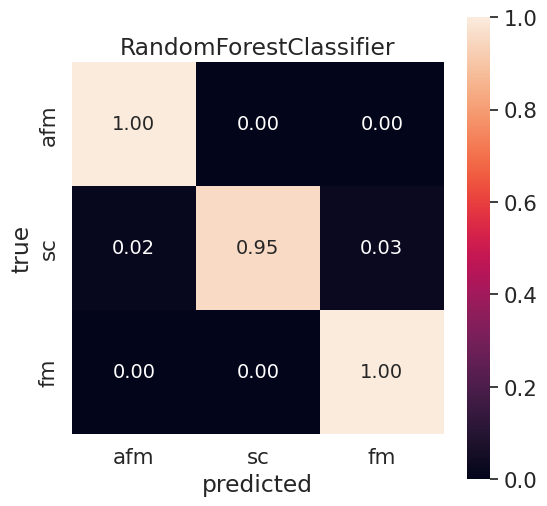

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.984125),
   'prec': 0.984125,
   'rec': 0.984125,
   'f1': 0.984125},
  array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [1.6906250e-02, 9.5478125e-01, 2.8312500e-02],
         [9.3750000e-04, 1.4687500e-03, 9.9759375e-01]]))}

In [18]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

# 1&emsp;trained on all vertices

* evaluate amount of information captured in latent space
* see how well the phase can be classified from the latent space

## 1-1&emsp;simple autoencoder

In [12]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/1_1_32'

In [ ]:
config_kwargs['batch_size'] = 8192 * 2
config_kwargs['num_dataloader_workers'] = 16
preds = verteval.predict_all(file_paths, vertices, save_path, config_kwargs, dataset_kwargs, encode_only=False)

In [ ]:
rmses = verteval.mean_rmse(file_paths, vertices, save_path)

mean: 0.007131751916505344, min: 0.003990790062044045, max: 0.01724117535137624


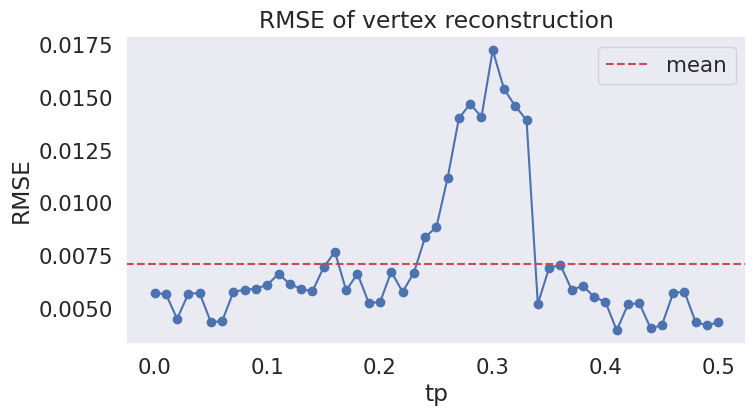

In [14]:
verteval.print_rmses(rmses)

In [ ]:
pc = PhaseClassification(save_path, pc_models, 11)
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/15 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

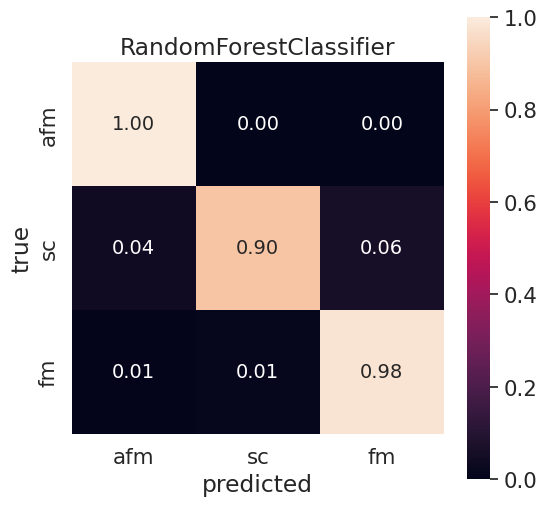

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9587541666666667),
   'prec': 0.9587541666666667,
   'rec': 0.9587541666666667,
   'f1': 0.9587541666666667},
  array([[1.        , 0.        , 0.        ],
         [0.042775  , 0.89615625, 0.06106875],
         [0.00733125, 0.0125625 , 0.98010625]]))}

In [13]:
model_scores = pc.evaluate_classifiers(test_dataset_full, print_conf_mat=True)
model_scores

## 1-2&emsp;contrastive autoencoder

In [5]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/1_2_32'

In [ ]:
preds = verteval.predict_all(file_paths, vertices, save_path, config_kwargs, dataset_kwargs, encode_only=False)

In [ ]:
rmses = verteval.mean_rmse(file_paths, vertices, save_path)

mean: 0.0806848330752778, min: 0.02365726265668881, max: 0.1771952141563764


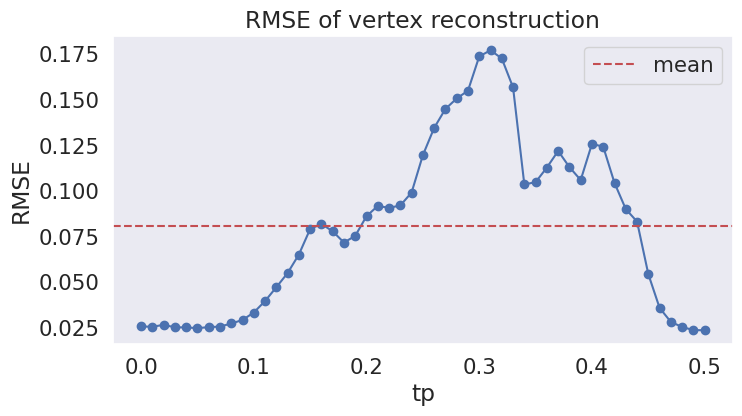

In [10]:
verteval.print_rmses(rmses)

In [ ]:
pc = PhaseClassification(save_path, pc_models, 12)
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/59 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

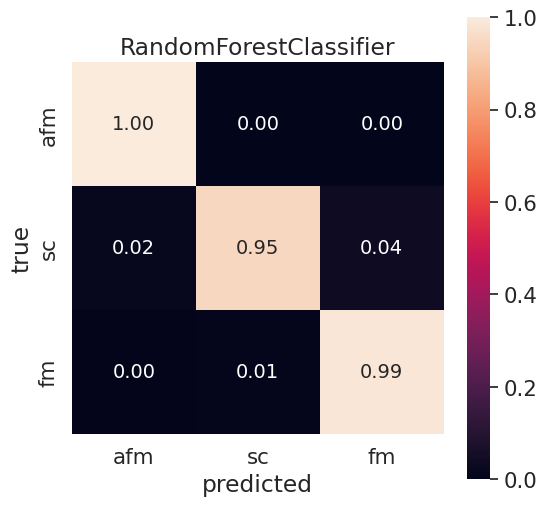

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9777729166666665),
   'prec': 0.9777729166666667,
   'rec': 0.9777729166666667,
   'f1': 0.9777729166666667},
  array([[1.        , 0.        , 0.        ],
         [0.015925  , 0.94809375, 0.03598125],
         [0.0039375 , 0.0108375 , 0.985225  ]]))}

In [8]:
model_scores = pc.evaluate_classifiers(test_dataset_full, print_conf_mat=True)
model_scores

# 2&emsp;trained on only 2 phases

* determine how well the phase can be extrapolated from latent space

## 2-1&emsp;exclude SC-phase

### 2-1-1&emsp;simple autoencoder

In [5]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/2_1_1_32'

In [ ]:
preds = verteval.predict_all(ex_sc_fps, vertices, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False, subset_type=['afm', 'fm'])

In [ ]:
rmses = verteval.mean_rmse(ex_sc_fps, vertices, save_path)

mean: 0.021328520361009566, min: 0.005658775649029629, max: 0.04587250367195385


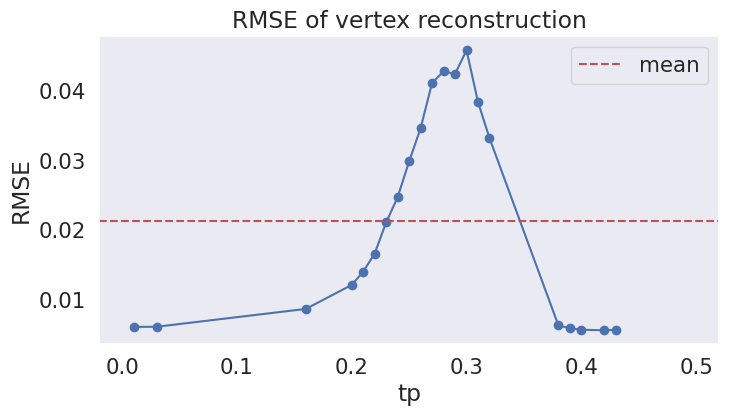

In [10]:
verteval.print_rmses(rmses)

In [19]:
pc = PhaseClassification(save_path, pc_models, 211)
pc.train(nce_train_dataset_subset)

Encode vertex samples:   0%|          | 0/36 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

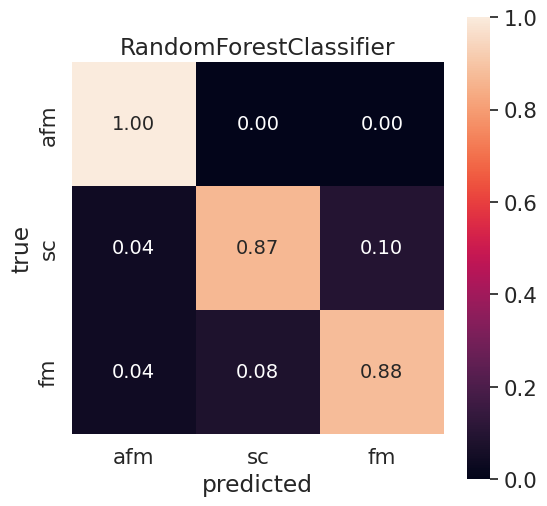

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9129583333333334),
   'prec': 0.9129583333333333,
   'rec': 0.9129583333333333,
   'f1': 0.9129583333333333},
  array([[0.9964375 , 0.002     , 0.0015625 ],
         [0.03965625, 0.86534375, 0.095     ],
         [0.04271875, 0.0801875 , 0.87709375]]))}

In [20]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

### 2-1-2&emsp;contrastive autoencoder

In [14]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/2_1_2_32'

In [ ]:
preds = verteval.predict_all(ex_sc_fps, vertices, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False, subset_type=['afm', 'fm'])

In [ ]:
rmses = verteval.mean_rmse(ex_sc_fps, vertices, save_path)

mean: 0.0747225484341053, min: 0.01117892377355485, max: 0.12125160756438419


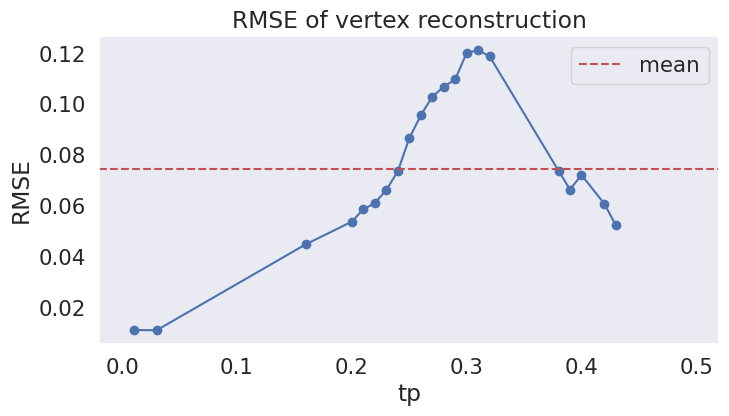

In [17]:
verteval.print_rmses(rmses)

In [25]:
pc = PhaseClassification(save_path, pc_models, 212)
pc.train(nce_train_dataset_subset)

Encode vertex samples:   0%|          | 0/141 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/12 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

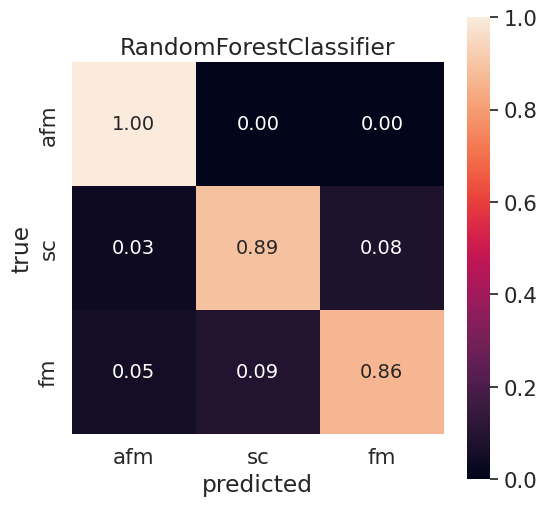

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9157083333333333),
   'prec': 0.9157083333333333,
   'rec': 0.9157083333333333,
   'f1': 0.9157083333333333},
  array([[9.9840625e-01, 5.9375000e-04, 1.0000000e-03],
         [3.2812500e-02, 8.8896875e-01, 7.8218750e-02],
         [4.7437500e-02, 9.2812500e-02, 8.5975000e-01]]))}

In [26]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

## 2-2&emsp;exclude AFM-phase

### 2-2-1&emsp;simple autoencoder

In [18]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/2_2_1_32'

In [ ]:
preds = verteval.predict_all(ex_afm_fps, vertices, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False, subset_type=['sc', 'fm'])

In [ ]:
rmses = verteval.mean_rmse(ex_afm_fps, vertices, save_path)

mean: 0.01604016292893231, min: 0.00589347971070677, max: 0.039119147992011154


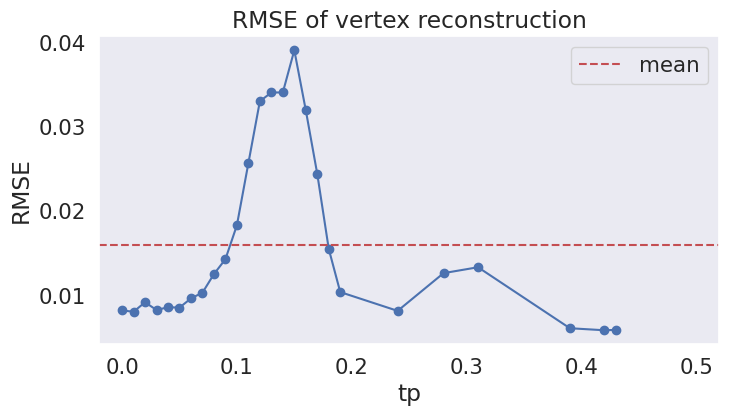

In [21]:
verteval.print_rmses(rmses)

In [31]:
pc = PhaseClassification(save_path, pc_models, 221)
pc.train(nce_train_dataset_subset)

Encode vertex samples:   0%|          | 0/36 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

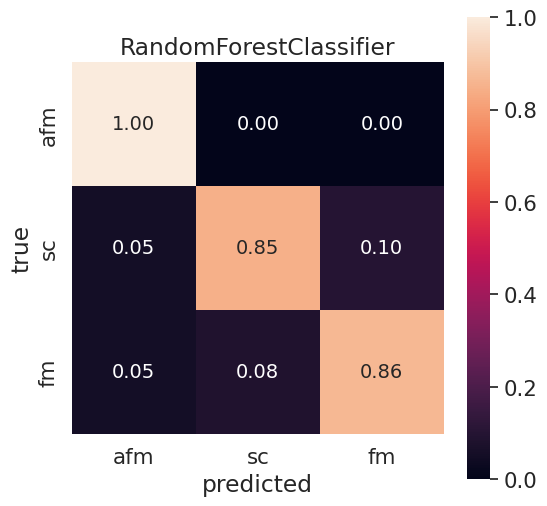

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9031770833333334),
   'prec': 0.9031770833333334,
   'rec': 0.9031770833333334,
   'f1': 0.9031770833333334},
  array([[9.9775000e-01, 1.5000000e-03, 7.5000000e-04],
         [5.1750000e-02, 8.4712500e-01, 1.0112500e-01],
         [5.1250000e-02, 8.4093750e-02, 8.6465625e-01]]))}

In [32]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

### 2-2-2&emsp;contrastive autoencoder

In [22]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/2_2_2_32'

In [ ]:
preds = verteval.predict_all(ex_afm_fps, vertices, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False, subset_type=['sc', 'fm'])

In [ ]:
rmses = verteval.mean_rmse(ex_afm_fps, vertices, save_path)

mean: 0.0646933823292771, min: 0.03284494152718744, max: 0.12064539524580181


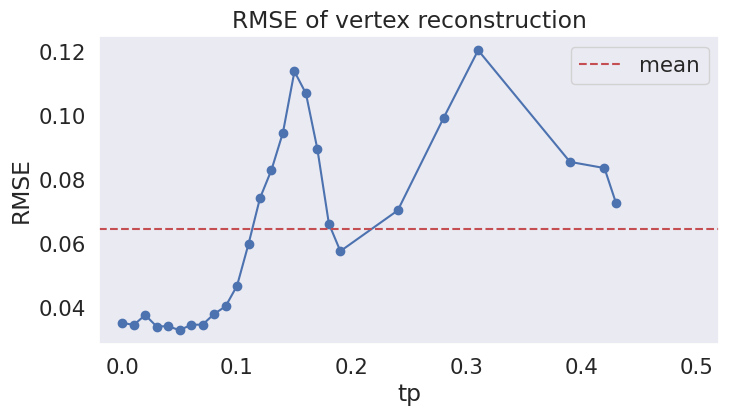

In [25]:
verteval.print_rmses(rmses)

In [36]:
pc = PhaseClassification(save_path, pc_models, 222)
pc.train(nce_train_dataset_subset)

Encode vertex samples:   0%|          | 0/141 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/12 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

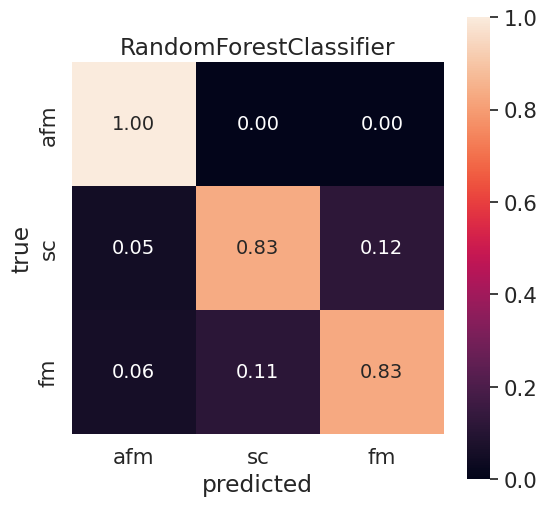

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.8865),
   'prec': 0.8865,
   'rec': 0.8865,
   'f1': 0.8865},
  array([[9.9818750e-01, 9.6875000e-04, 8.4375000e-04],
         [4.9906250e-02, 8.3209375e-01, 1.1800000e-01],
         [5.6125000e-02, 1.1465625e-01, 8.2921875e-01]]))}

In [37]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

## 2-3&emsp;exclude FM-phase

### 2-3-1&emsp;simple autoencoder

In [26]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/2_3_1_32'

In [ ]:
preds = verteval.predict_all(ex_fm_fps, vertices, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False, subset_type=['afm', 'sc'])

In [ ]:
rmses = verteval.mean_rmse(ex_fm_fps, vertices, save_path)

mean: 0.028120615564561042, min: 0.00795288233117042, max: 0.04996455791985712


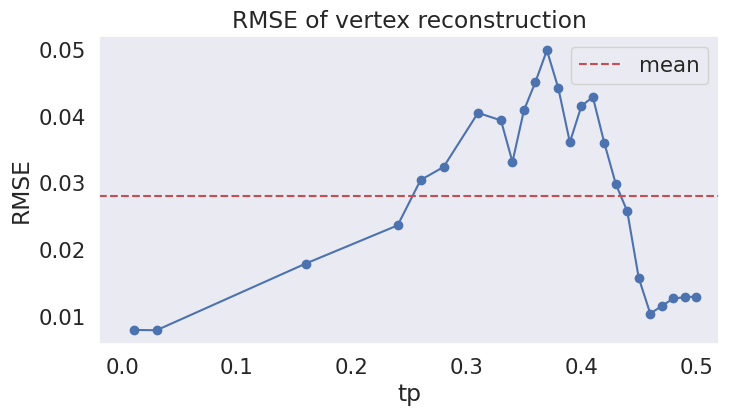

In [29]:
verteval.print_rmses(rmses)

In [47]:
pc = PhaseClassification(save_path, pc_models, 231)
pc.train(nce_train_dataset_subset)

Encode vertex samples:   0%|          | 0/36 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

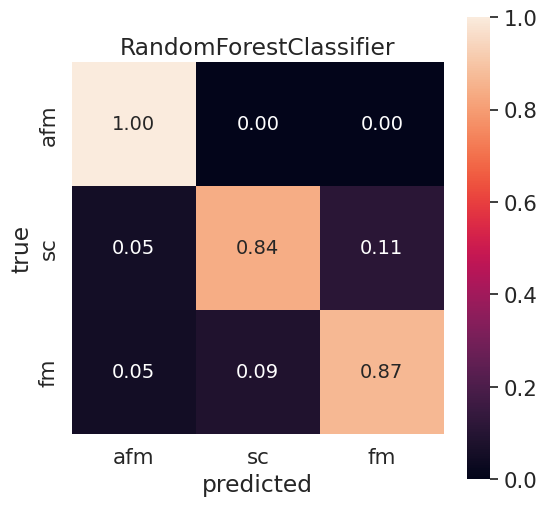

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9004479166666667),
   'prec': 0.9004479166666667,
   'rec': 0.9004479166666667,
   'f1': 0.9004479166666667},
  array([[0.99634375, 0.00221875, 0.0014375 ],
         [0.05121875, 0.837875  , 0.11090625],
         [0.04709375, 0.08578125, 0.867125  ]]))}

In [48]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

### 2-3-2&emsp;contrastive autoencoder

In [30]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/2_3_2_32'

In [ ]:
preds = verteval.predict_all(ex_fm_fps, vertices, save_path, config_kwargs, dataset_kwargs, 
                             encode_only=False, subset_type=['afm', 'sc'])

In [ ]:
rmses = verteval.mean_rmse(ex_fm_fps, vertices, save_path)

mean: 0.09713637169675275, min: 0.02652818876434128, max: 0.17184457209676032


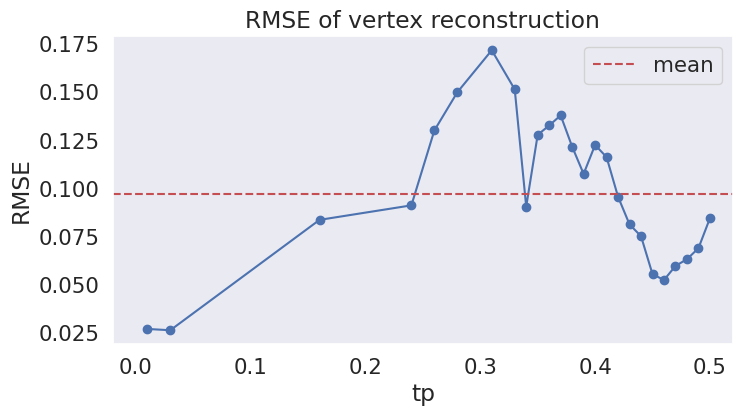

In [33]:
verteval.print_rmses(rmses)

In [53]:
pc = PhaseClassification(save_path, pc_models, 232)
pc.train(nce_train_dataset_subset)

Encode vertex samples:   0%|          | 0/141 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/12 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

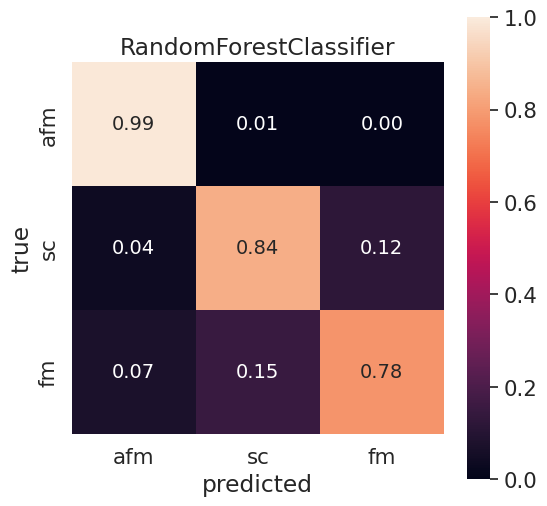

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.8697604166666667),
   'prec': 0.8697604166666667,
   'rec': 0.8697604166666667,
   'f1': 0.8697604166666667},
  array([[0.98840625, 0.007     , 0.00459375],
         [0.03903125, 0.8435    , 0.11746875],
         [0.07190625, 0.15071875, 0.777375  ]]))}

In [54]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

# 3&emsp;trained on only 1 phase

## 3-1&emsp;SC-phase

In [34]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/3_1_32'

In [ ]:
preds = verteval.predict_all(sc_fps, vertices, save_path, config_kwargs, dataset_kwargs, encode_only=False, subset_type='sc')

In [ ]:
rmses = verteval.mean_rmse(sc_fps, vertices, save_path)

mean: 0.025223883271459274, min: 0.00719361080394181, max: 0.056921028805340654


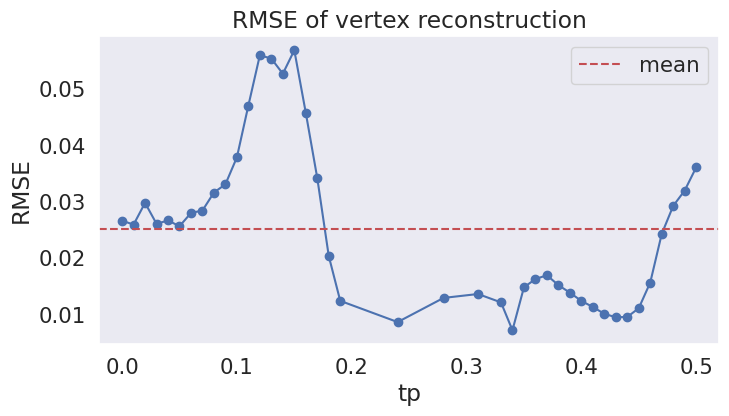

In [37]:
verteval.print_rmses(rmses)

In [ ]:
pc = PhaseClassification(save_path, pc_models, 31)
pc.train(nce_train_dataset_subset)

Encode vertex samples:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

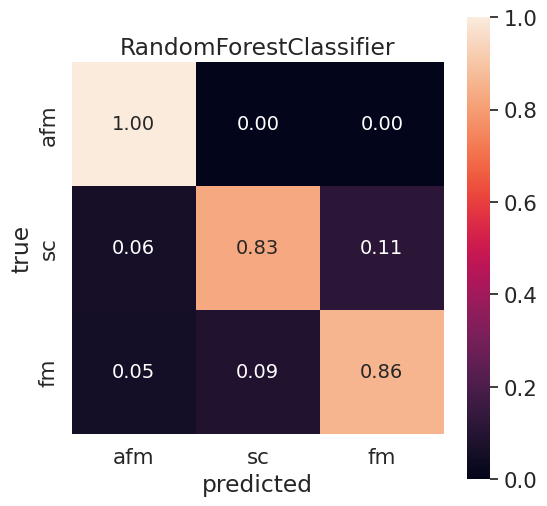

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.8943125000000002),
   'prec': 0.8943125,
   'rec': 0.8943125,
   'f1': 0.8943125},
  array([[0.996625  , 0.0019375 , 0.0014375 ],
         [0.05878125, 0.82753125, 0.1136875 ],
         [0.05140625, 0.0898125 , 0.85878125]]))}

In [10]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

## 3-2&emsp;AFM-phase

In [18]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/3_2_32'

In [ ]:
preds = verteval.predict_all(afm_fps, vertices, save_path, config_kwargs, dataset_kwargs, encode_only=False, subset_type='afm')

In [ ]:
rmses = verteval.mean_rmse(afm_fps, vertices, save_path)

mean: 0.06259161822113436, min: 0.006639772392829934, max: 0.12629827244327493


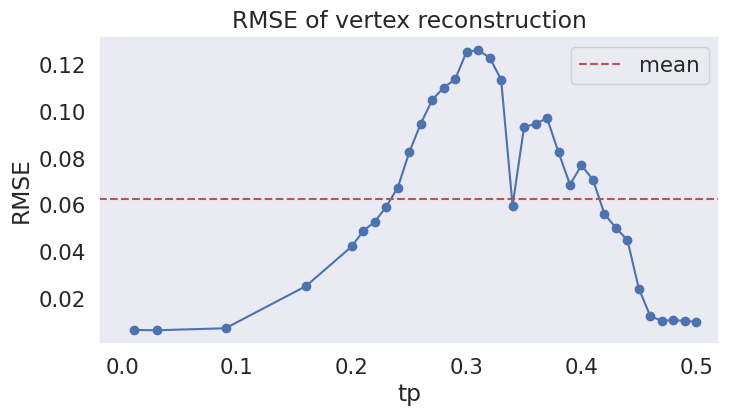

In [20]:
verteval.print_rmses(rmses)

In [ ]:
pc = PhaseClassification(save_path, pc_models, 32)
pc.train(nce_train_dataset_subset)

Encode vertex samples:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

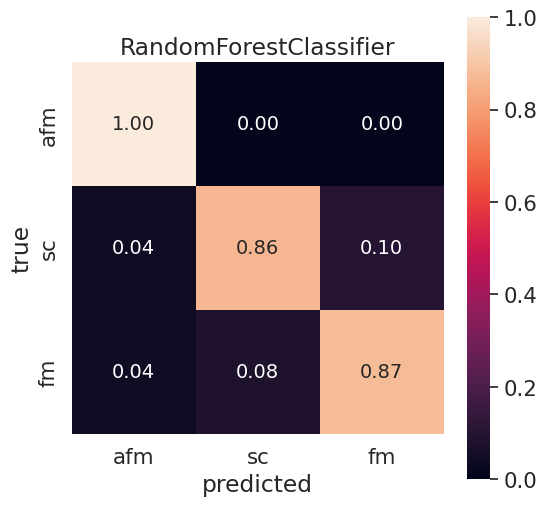

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9113541666666668),
   'prec': 0.9113541666666667,
   'rec': 0.9113541666666667,
   'f1': 0.9113541666666667},
  array([[0.99740625, 0.001375  , 0.00121875],
         [0.03803125, 0.862125  , 0.09984375],
         [0.0444375 , 0.08103125, 0.87453125]]))}

In [16]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

## 3-3&emsp;FM-phase

In [15]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/3_3_32'

In [ ]:
preds = verteval.predict_all(fm_fps, vertices, save_path, config_kwargs, dataset_kwargs, encode_only=False, subset_type='fm')

In [ ]:
rmses = verteval.mean_rmse(fm_fps, vertices, save_path)

mean: 0.06427614903911591, min: 0.02805096635264501, max: 0.1254708432011849


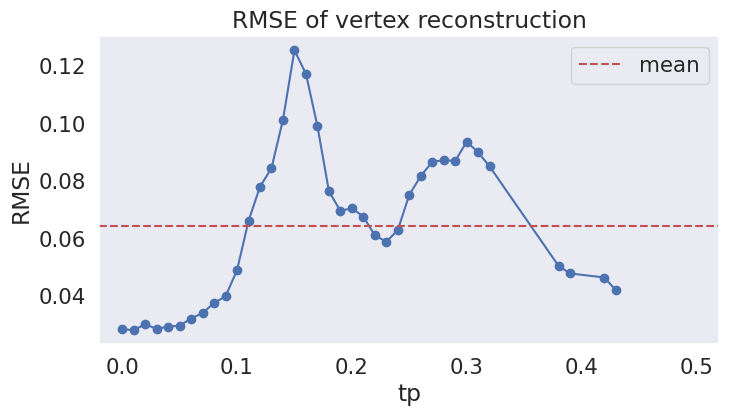

In [17]:
verteval.print_rmses(rmses)

In [13]:
pc = PhaseClassification(save_path, pc_models, 33)
pc.train(nce_train_dataset_subset)

Model RandomForestClassifier(n_jobs=-1, random_state=44) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


Encode vertex samples:   0%|          | 0/36 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

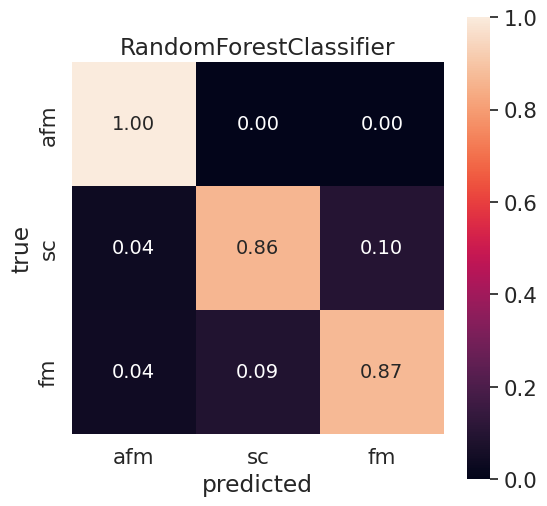

{'RandomForestClassifier(n_jobs=-1, random_state=44)': ({'acc': np.float64(0.9090729166666667),
   'prec': 0.9090729166666667,
   'rec': 0.9090729166666667,
   'f1': 0.9090729166666667},
  array([[0.99671875, 0.00190625, 0.001375  ],
         [0.038625  , 0.86      , 0.101375  ],
         [0.04115625, 0.08834375, 0.8705    ]]))}

In [14]:
model_scores = pc.evaluate_classifiers(test_dataset_subset, print_conf_mat=True)
model_scores

# correlation analysis

In [ ]:
# save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/1_1_32/latentspaces'
save_path = "/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-09/version_0/latentspaces"
cor_mat = verteval.vertex_correlation(vertex_dir=save_path, pre_load_vertices=True, 
                                      vertex_file_ending='npy')

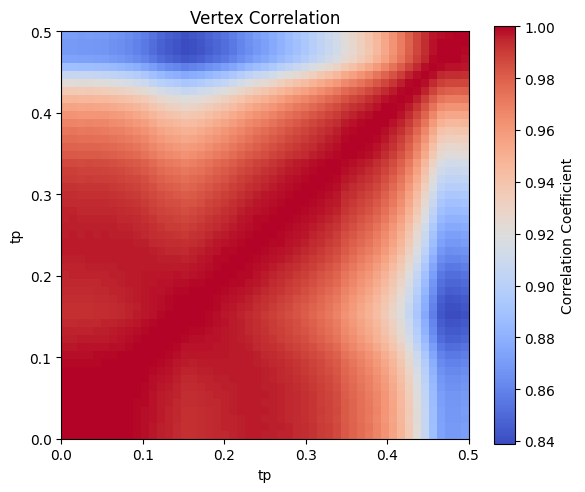

In [5]:
vertvis.plot_correlation(cor_mat, "Vertex Correlation")

## convergence

In [23]:
base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'
folders = [
    '1_1_32',
    '1_2_32',
    '2_1_1_32',
    '2_1_2_32',
    '2_2_1_32',
    '2_2_2_32',
    '2_3_1_32',
    '2_3_2_32',
    '3_1_32',
    '3_2_32',
    '3_3_32',
]
labels = [
    '1-1 all vertices, simple AE',
    '1-2 all vertices, contrastive AE',
    '2-1-1 exclude SC, simple AE',
    '2-1-2 exclude SC, contrastive AE',
    '2-2-1 exclude AFM, simple AE',
    '2-2-2 exclude AFM, contrastive AE',
    '2-3-1 exclude FM, simple AE',
    '2-3-2 exclude FM, contrastive AE',
    '3-1 SC only, simple AE',
    '3-2 AFM only, simple AE',
    '3-3 FM only, simple AE',
]
tensorboard_data = vis.get_tensorboard_data(base_path, folders, labels)

gb = tensorboard_data.groupby('run')
(gb['wall_time'].max() - gb['wall_time'].min()) / 3600

run
1-1 all vertices, simple AE          35.962006
1-2 all vertices, contrastive AE     14.954386
2-1-1 exclude SC, simple AE          24.261188
2-1-2 exclude SC, contrastive AE      7.726222
2-2-1 exclude AFM, simple AE         19.914375
2-2-2 exclude AFM, contrastive AE    72.316074
2-3-1 exclude FM, simple AE          20.739043
2-3-2 exclude FM, contrastive AE      7.728976
3-1 SC only, simple AE                8.229717
3-2 AFM only, simple AE              12.825107
3-3 FM only, simple AE               11.290330
Name: wall_time, dtype: float64

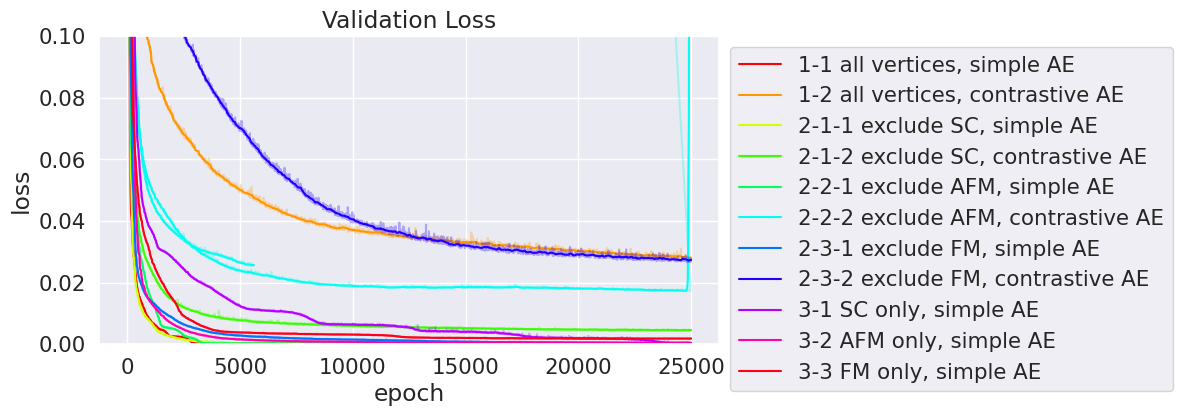

In [24]:
vis.plot_loss_progress(tensorboard_data.dropna(), labels, y_max=0.1, log=False)

# 0x U-Net

In [ ]:
info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32]
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'model_name': 'UNetVertex',
                 'hidden_dims': hidden_dims,
                 'epochs': 1000,
                 'sample_count_per_vertex': 2000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': False, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 8, 
                 'strategy': 'auto', 
                 'batch_size': 4096}


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## train

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, hidden_dims)

## evaluate prediction

In [ ]:
test_file = 'tp0.020000_mu0.080000.h5'
test_file3d = '../../../frgs/' + test_file
test_file6d = '../../../frgs_6d/' + test_file

info = verteval.load_info_dict(info_fn)

vertex3 = AutoEncoderVertexDataset.load_from_file(test_file3d)
vertex6 = AutoEncoderVertex24x6Dataset.load_from_file(test_file6d)

keys = [f'n={x['latent_dim']}' for x in info]
trainer = init_trainer(device_type='cpu', batch_size=1024, num_dataloader_workers=8)

i = 18
axis = trainer.config.construction_axis
k, other_k = (axis + 1) // 2, 3
slice_idx_3d = i * 24 + i
nrows, ncols = 2, 3

### predict 24x24 slice

In [ ]:
# RESULTS FOR 2-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i, i, i), axis, keys, nrows, ncols, 
                             trainer.predict_slice2d, fixed_idcs=(i, i, i, i))

### predict 576x576 slice

In [ ]:
# RESULTS FOR 4-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i), (k, other_k), keys, nrows, ncols, 
                             trainer.predict_slice4d, fixed_idcs=(i, i), other_k=other_k)

### predict full vertex

In [ ]:
# RESULTS FOR 6-DIMENSIONAL PREDICTION
# for 6d-data
slice_at = (i, i, i, i)
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, slice_at, axis, keys, nrows, ncols, 
                             predict_func=trainer.predict)

In [ ]:
# for 3d-data
slice_at = slice_idx_3d
verteval.evaluate_and_report(info, test_file3d, trainer, vertex3, slice_at, axis, keys, nrows, ncols, 
                             load_func=trainer.load_prediction)

# ---